# Hierarchical S2 Grid Demo

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from torch_so3.hierarchical_s2_grid import HierarchicalS2Grid

plt.rcParams["figure.dpi"] = 150

## 1. Constructing a grid

`HierarchicalS2Grid(nside_finest, n_levels)` builds `n_levels` HEALPix resolutions,
each a factor of 2 coarser than the next, down from `nside_finest`. `levels[0]` is
the coarsest, `levels[-1]` is the finest.

In [2]:
grid = HierarchicalS2Grid(nside_finest=32, n_levels=4)

print(f"{'level':>5} {'depth':>5} {'nside':>6} {'npix':>6} {'step (deg)':>12}")
for level_idx, level in enumerate(grid.levels):
    print(
        f"{level_idx:>5} {level.depth:>5} {level.nside:>6} "
        f"{level.npix:>6} {level.s2_step_deg:>12.3f}"
    )

level depth  nside   npix   step (deg)
    0     3      4    192       14.650
    1     2      8    768        7.325
    2     1     16   3072        3.663
    3     0     32  12288        1.831


`from_target_step_deg` is a convenience constructor that picks the finest `nside`
closest to a target angular step size (rounded to the nearest power of 2).

In [3]:
target_step_deg = 2.0

step_grid = HierarchicalS2Grid.from_target_step_deg(
    target_step_deg=target_step_deg, n_levels=4
)
finest = step_grid.get_level(step_grid.n_levels - 1)
print(
    f"target step: {target_step_deg} deg -> nside_finest={step_grid.nside_finest}, "
    f"actual step={finest.s2_step_deg:.3f} deg"
)

target step: 2.0 deg -> nside_finest=32, actual step=1.831 deg


## 2. Visualizing grid points at each resolution level

Each level's pixel centers are plotted on a Mollweide (equal-area) projection of the sphere. Coarser levels have fewer, more widely-spaced points; finer levels are denser.

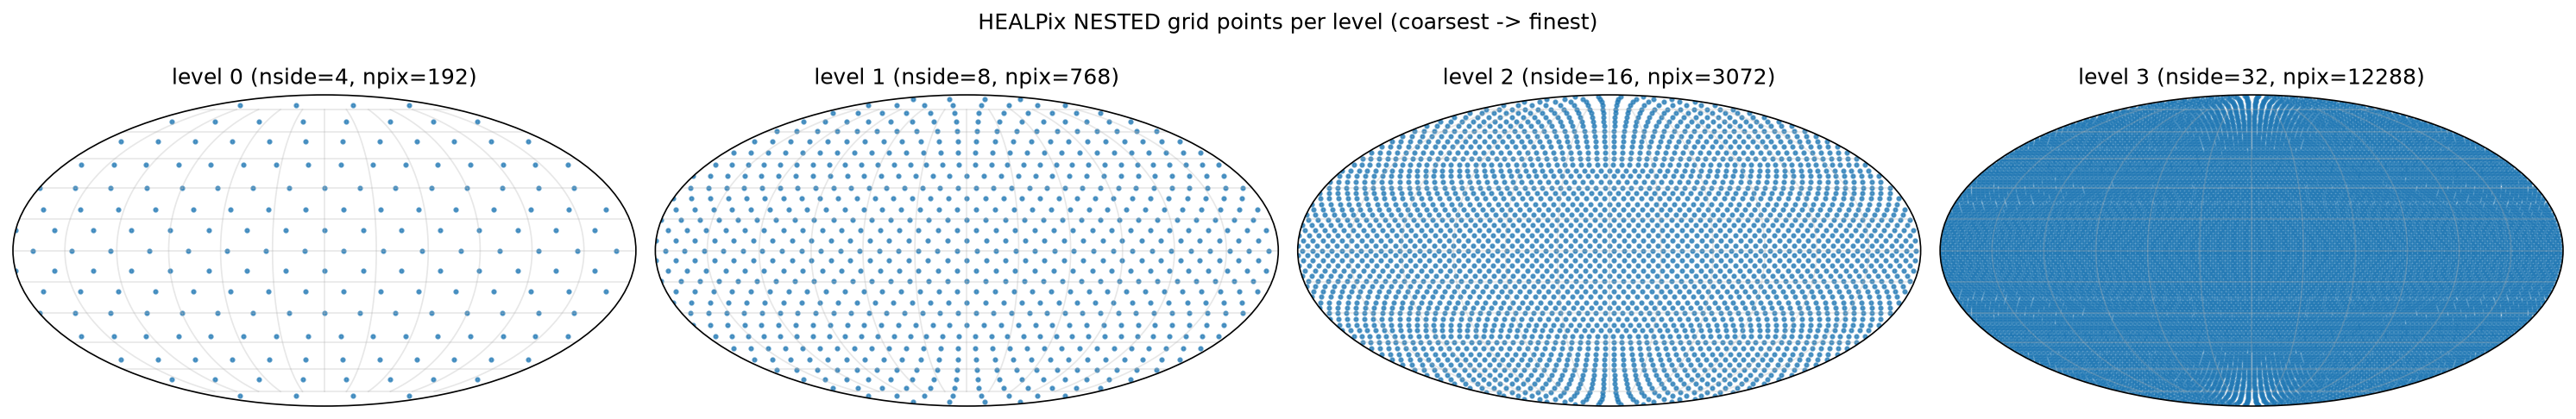

In [4]:
def to_mollweide_coords(theta_deg, phi_deg):
    """Convert HEALPix (colatitude, longitude), in degrees, to Mollweide (lon, lat) radians."""
    theta = np.radians(theta_deg)
    phi = np.radians(phi_deg)
    lat = np.pi / 2 - theta
    lon = ((phi + np.pi) % (2 * np.pi)) - np.pi
    return lon, lat


fig, axes = plt.subplots(
    1,
    grid.n_levels,
    figsize=(5 * grid.n_levels, 3.5),
    subplot_kw={"projection": "mollweide"},
)
for level_idx, ax in enumerate(axes):
    theta_deg, phi_deg = grid.get_level_orientations(level_idx)
    lon, lat = to_mollweide_coords(theta_deg, phi_deg)
    level = grid.get_level(level_idx)
    ax.scatter(lon, lat, s=4, alpha=0.7)
    ax.set_title(f"level {level_idx} (nside={level.nside}, npix={level.npix})")
    ax.grid(True, alpha=0.3)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

fig.suptitle("HEALPix NESTED grid points per level (coarsest -> finest)")
fig.tight_layout()
plt.show()

## 3. Validating `followup`

`followup(ipix, source_level, target_level, rings)` starts from a pixel index `ipix` at `source_level`'s resolution and returns the indices of nearby pixels at `target_level`. Internally it:

1. Finds the `rings`-neighborhood of `ipix` at `source_level` (via `neighbor_indices`, a BFS over HEALPix neighbor lookups).
2. Converts every pixel in that neighborhood to `target_level`'s resolution (via `convert_index`) — coarsening is many-to-one (a right-shift), refining is one-to-many (a left-shift plus enumerating child pixels).


In [5]:
demo_grid = HierarchicalS2Grid(nside_finest=32, n_levels=3)
finest_level_idx = demo_grid.finest_level
finest = demo_grid.get_level(finest_level_idx)

theta_f, phi_f = demo_grid.get_level_orientations(finest_level_idx)

query_ipix = 1234
theta_q, phi_q = demo_grid.angle_from_index(query_ipix, level=finest_level_idx)

print(f"query pixel: ipix={query_ipix}, theta={theta_q:.2f} deg, phi={phi_q:.2f} deg")

query pixel: ipix=1234, theta=62.72 deg, phi=139.22 deg


### 3a. Same-level followup

`neighbor_indices` (and therefore `followup`) always includes the query pixel
itself, plus its `rings`-neighborhood. With `target_level` equal to
`source_level` and `rings=1`, we expect the query pixel plus its 8 immediate
HEALPix neighbors.

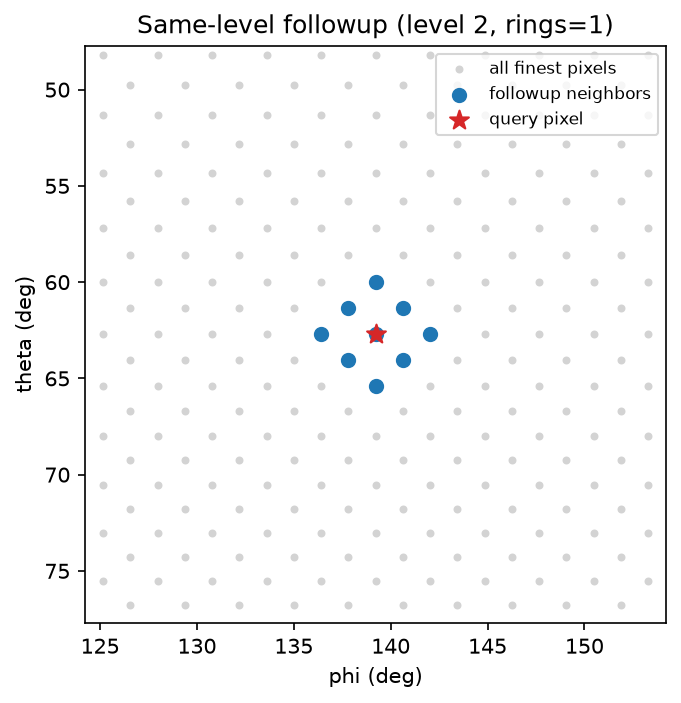

same-level neighbors (9):
	[1221, 1223, 1229, 1232, 1233, 1234, 1235, 1240, 1241]
	[[(139.22, 65.38), (137.81, 64.06), (136.41, 62.72), (140.62, 64.06), (142.03, 62.72), (139.22, 62.72), (140.62, 61.37), (137.81, 61.37), (139.22, 60.0)]]


In [6]:
same_level_neighbors = demo_grid.followup(
    ipix=query_ipix,
    source_level=finest_level_idx,
    target_level=finest_level_idx,
    rings=1,
)
theta_n, phi_n = demo_grid.angle_from_index(
    same_level_neighbors, level=finest_level_idx
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    phi_f,
    theta_f,
    s=8,
    color="lightgray",
    label="all finest pixels",
)
ax.scatter(
    phi_n,
    theta_n,
    s=40,
    color="tab:blue",
    label="followup neighbors",
)
ax.scatter(
    [phi_q],
    [theta_q],
    s=90,
    color="tab:red",
    marker="*",
    label="query pixel",
)
ax.set_xlim(phi_q - 15, phi_q + 15)
ax.set_ylim(theta_q + 15, theta_q - 15)
ax.set_xlabel("phi (deg)")
ax.set_ylabel("theta (deg)")
ax.set_title(f"Same-level followup (level {finest_level_idx}, rings=1)")
ax.legend(loc="upper right", fontsize=8)
plt.show()

assert query_ipix in same_level_neighbors, (
    "query pixel should be included in its own neighborhood"
)
print(
    f"same-level neighbors ({len(same_level_neighbors)}):\n"
    f"\t{sorted(same_level_neighbors.tolist())}\n"
    f"\t[{[(p.round(2).item(), t.round(2).item()) for p, t in zip(phi_n, theta_n)]}]"
)

### 3b. Coarse -> fine followup (the intended search pattern)

We query the coarse pixel that contains our (finest-level) query point, then `followup` to the finest level.
For comparison, `convert_index` alone (no neighbor margin) gives just that coarse pixel's own children — `followup` with `rings=1` should return a superset that also covers a bit past the coarse cell's boundary, in case the true optimum lies just outside it.

In [7]:
coarse_level_idx = 0

theta_q_coarse = 87.0
phi_q_coarse = 170.0
coarse_query_ipix = demo_grid.index_from_angle(
    theta_q_coarse, phi_q_coarse, level=coarse_level_idx
)
coarse_query_ipix

theta_actual, phi_actual = demo_grid.angle_from_index(
    coarse_query_ipix, level=coarse_level_idx
)
print(
    f"coarse query pixel: ipix={coarse_query_ipix}, "
    f"theta={theta_actual:.2f} deg, phi={phi_actual:.2f} deg"
)

coarse query pixel: ipix=423, theta=85.22 deg, phi=168.75 deg


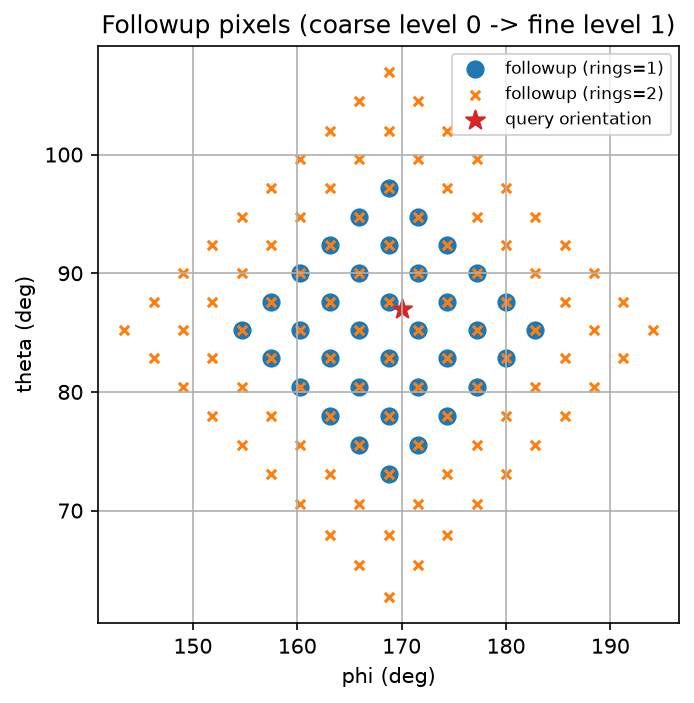

In [8]:
fine_level_idx = 1

# Find the follow-up pixels surrounding the coarsely queried orientation
followup_candidates_ring1 = demo_grid.followup(
    ipix=coarse_query_ipix,
    source_level=coarse_level_idx,
    target_level=fine_level_idx,
    rings=1,
)
followup_candidates_ring2 = demo_grid.followup(
    ipix=coarse_query_ipix,
    source_level=coarse_level_idx,
    target_level=fine_level_idx,
    rings=2,
)
theta_f1, phi_f1 = demo_grid.angle_from_index(
    followup_candidates_ring1, level=fine_level_idx
)
theta_f2, phi_f2 = demo_grid.angle_from_index(
    followup_candidates_ring2, level=fine_level_idx
)

# Local scatter plot of the follow-up pixels at the finer level
plt.figure(figsize=(5, 5))
plt.scatter(
    phi_f1,
    theta_f1,
    s=60,
    color="tab:blue",
    label="followup (rings=1)",
)
plt.scatter(
    phi_f2,
    theta_f2,
    s=20,
    marker="x",
    color="tab:orange",
    label="followup (rings=2)",
)
plt.scatter(
    [phi_q_coarse],
    [theta_q_coarse],
    s=90,
    color="tab:red",
    marker="*",
    label="query orientation",
)
plt.xlabel("phi (deg)")
plt.ylabel("theta (deg)")
plt.title(
    f"Followup pixels (coarse level {coarse_level_idx} -> fine level {fine_level_idx})"
)
plt.legend(loc="upper right", fontsize=8)
plt.grid()
plt.show()

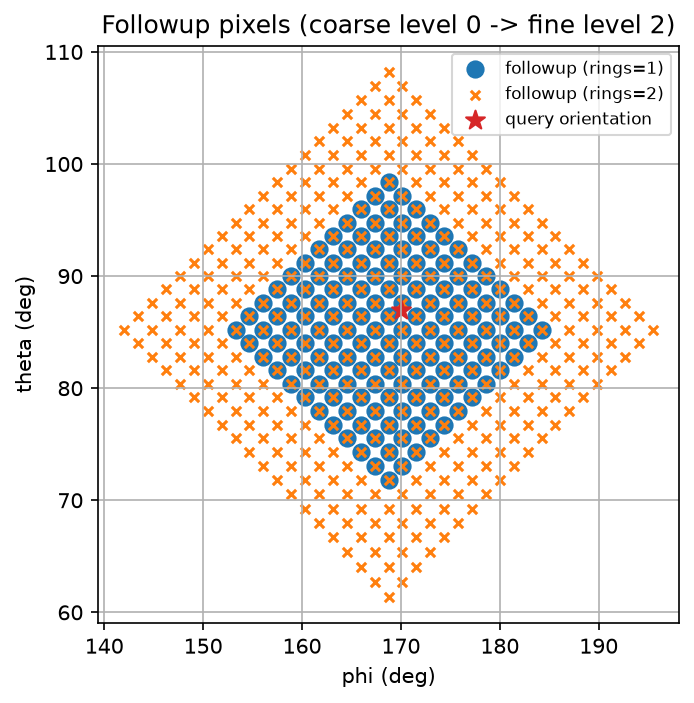

In [9]:
fine_level_idx = 2

# Find the follow-up pixels surrounding the coarsely queried orientation
followup_candidates_ring1 = demo_grid.followup(
    ipix=coarse_query_ipix,
    source_level=coarse_level_idx,
    target_level=fine_level_idx,
    rings=1,
)
followup_candidates_ring2 = demo_grid.followup(
    ipix=coarse_query_ipix,
    source_level=coarse_level_idx,
    target_level=fine_level_idx,
    rings=2,
)
theta_f1, phi_f1 = demo_grid.angle_from_index(
    followup_candidates_ring1, level=fine_level_idx
)
theta_f2, phi_f2 = demo_grid.angle_from_index(
    followup_candidates_ring2, level=fine_level_idx
)

# Local scatter plot of the follow-up pixels at the finer level
plt.figure(figsize=(5, 5))
plt.scatter(
    phi_f1,
    theta_f1,
    s=60,
    color="tab:blue",
    label="followup (rings=1)",
)
plt.scatter(
    phi_f2,
    theta_f2,
    s=20,
    marker="x",
    color="tab:orange",
    label="followup (rings=2)",
)
plt.scatter(
    [phi_q_coarse],
    [theta_q_coarse],
    s=90,
    color="tab:red",
    marker="*",
    label="query orientation",
)
plt.xlabel("phi (deg)")
plt.ylabel("theta (deg)")
plt.title(
    f"Followup pixels (coarse level {coarse_level_idx} -> fine level {fine_level_idx})"
)
plt.legend(loc="upper right", fontsize=8)
plt.grid()
plt.show()

### 3d. Effect of `rings`

Increasing `rings` should grow the neighborhood monotonically while staying
centered on the query point.

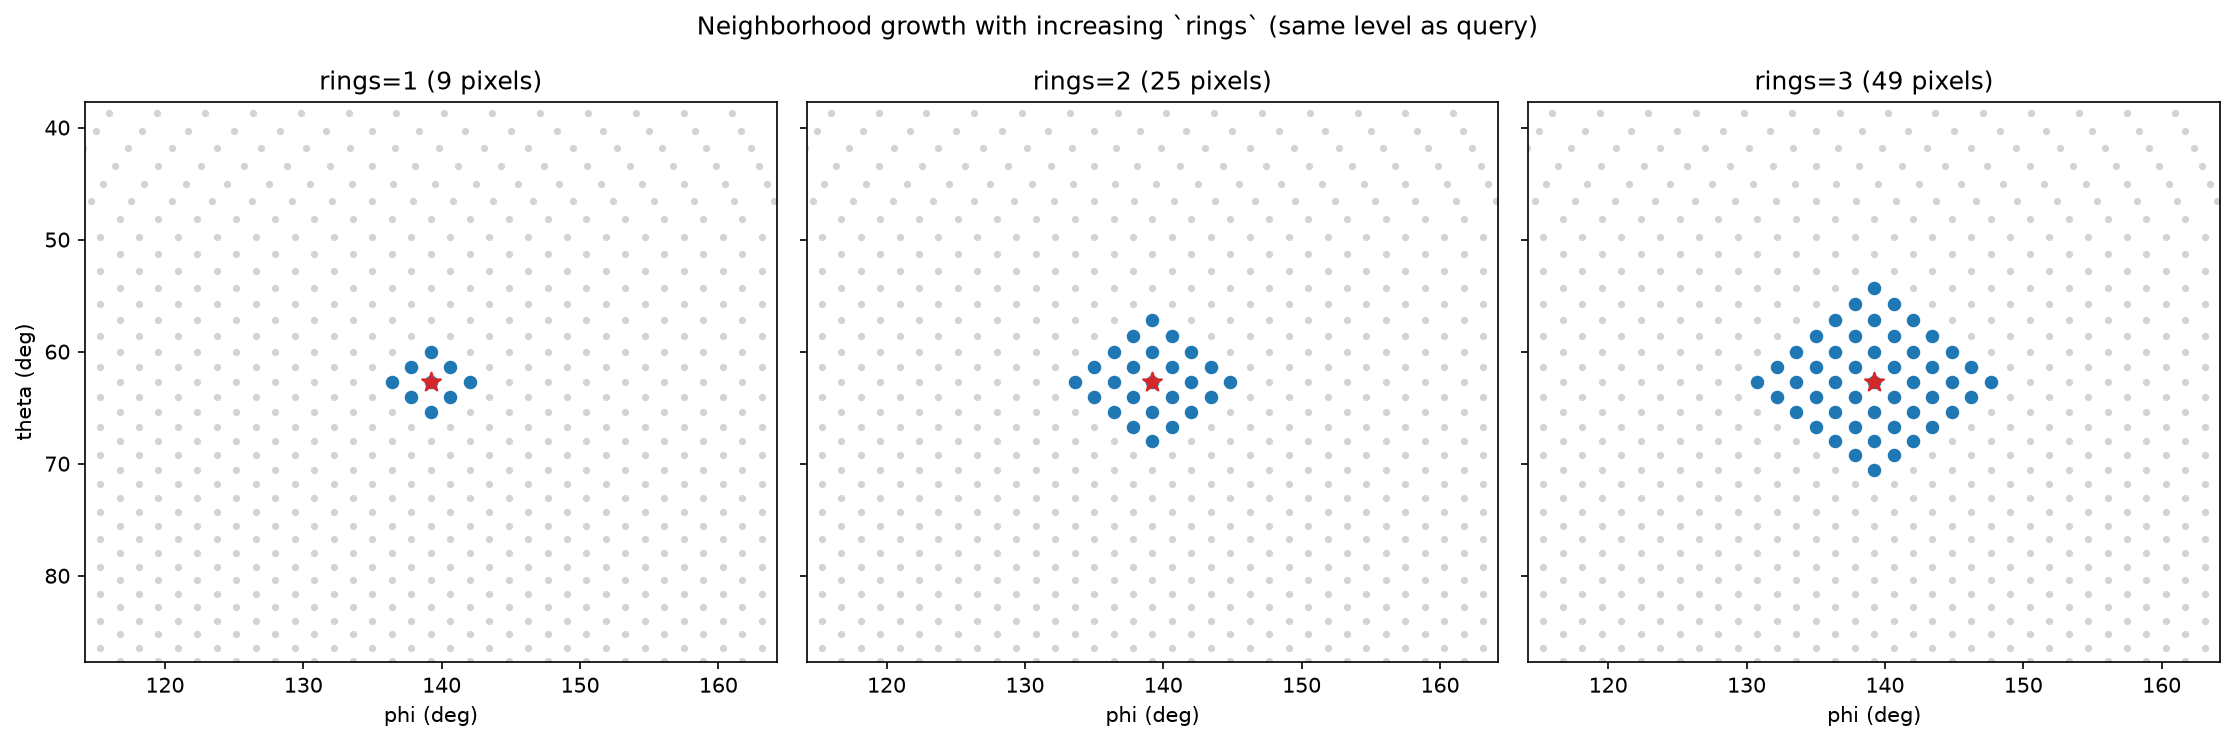

pixel counts by rings [1, 2, 3]: [9, 25, 49]


In [10]:
ring_values = [1, 2, 3]
fig, axes = plt.subplots(
    1, len(ring_values), figsize=(5 * len(ring_values), 5), sharex=True, sharey=True
)

counts = []
for ax, rings in zip(axes, ring_values):
    neighbors = demo_grid.followup(
        ipix=query_ipix,
        source_level=finest_level_idx,
        target_level=finest_level_idx,
        rings=rings,
    )
    counts.append(len(neighbors))
    theta_n, phi_n = demo_grid.angle_from_index(neighbors, level=finest_level_idx)

    ax.scatter(phi_f, theta_f, s=6, color="lightgray")
    ax.scatter(phi_n, theta_n, s=30, color="tab:blue")
    ax.scatter([phi_q], [theta_q], s=90, color="tab:red", marker="*")
    ax.set_title(f"rings={rings} ({len(neighbors)} pixels)")
    ax.set_xlim(phi_q - 25, phi_q + 25)
    ax.set_ylim(theta_q + 25, theta_q - 25)
    ax.set_xlabel("phi (deg)")
axes[0].set_ylabel("theta (deg)")

fig.suptitle("Neighborhood growth with increasing `rings` (same level as query)")
fig.tight_layout()
plt.show()

assert counts == sorted(counts), "pixel count should grow monotonically with rings"
print(f"pixel counts by rings {ring_values}: {counts}")